# **AULA DE TESTE DE HIPOTESE**

![Alt text](https://www.laboneconsultoria.com.br/wp-content/uploads/2021/06/Tipos-de-teste-de-hip%C3%B3teses.jpg)

###**1. O QUE É TESTE DE HIPÓTESE?**

É uma técnica estatística usada para verificar se uma afirmação sobre uma população
faz sentido com base em uma amostra de dados.

Exemplo:
Uma empresa afirma que o tempo médio de entrega é de 30 minutos.
Será que os dados reais confirmam isso?

Para testar, usamos duas hipóteses:

*   **H0: hipótese nula** - É a hipótese inicial. Normalmente diz que não existe diferença ou mudança.
*   **H1: hipótese alternativa** - É a hipótese que queremos investigar. Normalmente diz que existe diferença ou mudança.

### **2. EXEMPLO PRÁTICO**

SITUAÇÃO: Uma empresa de logística afirma que o tempo médio de entrega é de 30 minutos.

Vamos coletar uma amostra de entregas e verificar se o tempo médio real
é diferente de 30 minutos.

* **H0:** o tempo médio de entrega é igual a 30 minutos
* **H1:** o tempo médio de entrega é diferente de 30 minutos

**Exemplo no Proximo Slide -->**



In [54]:
# Importando bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Criando uma amostra simulada de tempos de entrega
np.random.seed(42)

tempos_entrega = np.array([
    32, 34, 29, 31, 35, 33, 30, 36, 34, 32,
    31, 33, 37, 29, 34, 35, 32, 31, 36, 33
])

# Transformando em DataFrame
df = pd.DataFrame({
    "Tempo de Entrega": tempos_entrega
})

df.head()

,Tempo de Entrega
0,32
1,34
2,29
3,31
4,35


In [55]:
# ============================================================
# 3. ANÁLISE DESCRITIVA
# ============================================================

media_amostra = df["Tempo de Entrega"].mean()
desvio_padrao = df["Tempo de Entrega"].std()
tamanho_amostra = len(df)

print("Média da amostra:", round(media_amostra, 2))
print("Desvio padrão da amostra:", round(desvio_padrao, 2))
print("Tamanho da amostra:", tamanho_amostra)

Média da amostra: 32.85
Desvio padrão da amostra: 2.3
Tamanho da amostra: 20


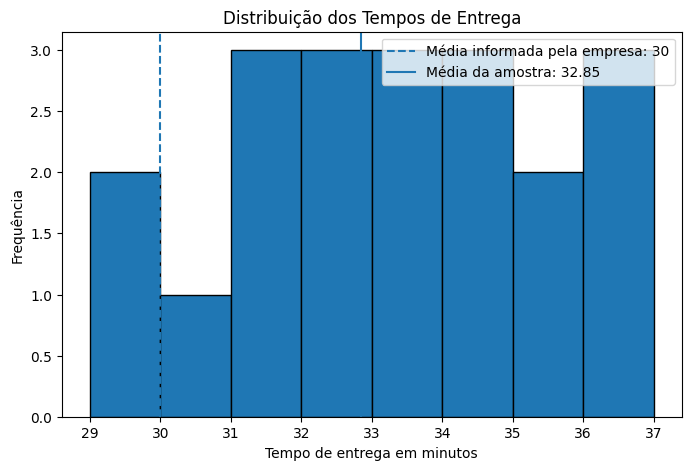

In [56]:
# ============================================================
# 4. VISUALIZAÇÃO DOS DADOS
# ============================================================

plt.figure(figsize=(8,5))
plt.hist(df["Tempo de Entrega"], bins=8, edgecolor="black")
plt.axvline(30, linestyle="--", label="Média informada pela empresa: 30")
plt.axvline(media_amostra, linestyle="-", label=f"Média da amostra: {media_amostra:.2f}")
plt.title("Distribuição dos Tempos de Entrega")
plt.xlabel("Tempo de entrega em minutos")
plt.ylabel("Frequência")
plt.legend()
plt.show()

### **5. DEFININDO O NÍVEL DE SIGNIFICÂNCIA**

NÍVEL DE SIGNIFICÂNCIA

O nível de significância é a margem de erro que aceitamos no teste.

O mais comum é usar 5%, ou seja:

* alfa = 0.05

Se o p-valor for menor que 0.05, rejeitamos H0.
Se o p-valor for maior ou igual a 0.05, não rejeitamos H0.



In [57]:
alfa = 0.05
media_hipotese = 30

In [58]:
# ============================================================
# 6. APLICANDO O TESTE T DE UMA AMOSTRA
# ============================================================

# Teste t para uma amostra
estatistica_t, p_valor = stats.ttest_1samp(df["Tempo de Entrega"], media_hipotese)

print("Estatística t:", round(estatistica_t, 4))
print("P-valor:", round(p_valor, 4))

Estatística t: 5.5405
P-valor: 0.0


In [59]:
# ============================================================
# 7. INTERPRETANDO O RESULTADO
# ============================================================

if p_valor < alfa:
    print("""
RESULTADO:

Como o p-valor é menor que 0.05, rejeitamos a hipótese nula.

Conclusão:
Há evidências estatísticas de que o tempo médio de entrega é diferente de 30 minutos.
""")
else:
    print("""
RESULTADO:

Como o p-valor é maior ou igual a 0.05, não rejeitamos a hipótese nula.

Conclusão:
Não há evidências suficientes para afirmar que o tempo médio de entrega é diferente de 30 minutos.
""")


RESULTADO:

Como o p-valor é menor que 0.05, rejeitamos a hipótese nula.

Conclusão:
Há evidências estatísticas de que o tempo médio de entrega é diferente de 30 minutos.



### **8. EXPLICAÇÃO SIMPLES DO P-VALOR**

O p-valor mostra a chance de encontrarmos um resultado parecido com o da amostra,considerando que a hipótese nula seja verdadeira.

Na prática:

* p-valor pequeno: O resultado da amostra é pouco provável se H0 for verdadeira.
Então rejeitamos H0.

* p-valor grande: O resultado da amostra ainda é compatível com H0.
Então não rejeitamos H0.

### **9. EXEMPLO COMPARANDO DUAS MÉDIAS**

SEGUNDO EXEMPLO:

Agora vamos comparar o tempo médio de entrega de dois turnos.

* H0: as médias dos dois turnos são iguais
* H1: as médias dos dois turnos são diferentes

**Segue Exmplo no proximo Slide -->**

In [60]:
turno_1 = np.array([30, 31, 29, 32, 30, 33, 31, 30, 29, 32])
turno_2 = np.array([35, 34, 36, 33, 37, 35, 34, 36, 38, 35])

df_turnos = pd.DataFrame({
    "Turno 1": turno_1,
    "Turno 2": turno_2
})

df_turnos

,Turno 1,Turno 2
0,30,35
1,31,34
2,29,36
3,32,33
4,30,37
5,33,35
6,31,34
7,30,36
8,29,38
9,32,35


In [61]:
# Médias dos turnos

media_t1 = turno_1.mean()
media_t2 = turno_2.mean()

print("Média do Turno 1:", round(media_t1, 2))
print("Média do Turno 2:", round(media_t2, 2))

Média do Turno 1: 30.7
Média do Turno 2: 35.3


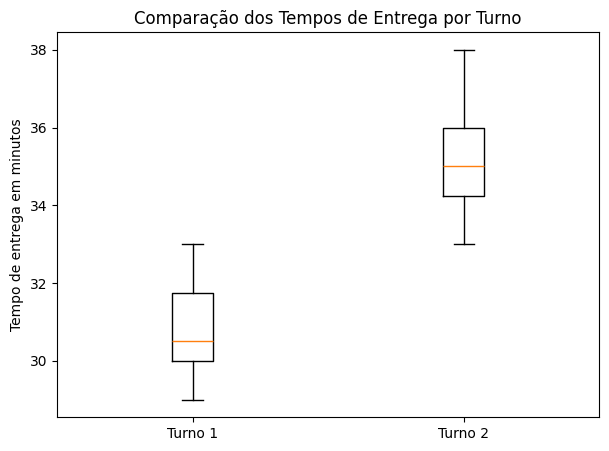

In [62]:
# Gráfico comparativo

plt.figure(figsize=(7,5))
plt.boxplot([turno_1, turno_2], tick_labels=["Turno 1", "Turno 2"])
plt.title("Comparação dos Tempos de Entrega por Turno")
plt.ylabel("Tempo de entrega em minutos")
plt.show()

In [63]:
# Teste t para duas amostras independentes

estatistica_t2, p_valor2 = stats.ttest_ind(turno_1, turno_2)

print("Estatística t:", round(estatistica_t2, 4))
print("P-valor:", round(p_valor2, 4))

if p_valor2 < alfa:
    print("""
RESULTADO:

Como o p-valor é menor que 0.05, rejeitamos H0.

Conclusão:
Existe diferença estatisticamente significativa entre os tempos médios dos dois turnos.
""")
else:
    print("""
RESULTADO:

Como o p-valor é maior ou igual a 0.05, não rejeitamos H0.

Conclusão:
Não há evidências suficientes para afirmar que os turnos possuem médias diferentes.
""")

Estatística t: -7.2531
P-valor: 0.0

RESULTADO:

Como o p-valor é menor que 0.05, rejeitamos H0.

Conclusão:
Existe diferença estatisticamente significativa entre os tempos médios dos dois turnos.



### **10. RESUMO FINAL PARA A AULA**

1. Teste de hipótese serve para tomar decisão com base em dados.

2. Sempre começamos com duas hipóteses:
   H0: hipótese nula
   H1: hipótese alternativa

3. O nível de significância mais usado é 5%.

4. O p-valor ajuda a decidir:
   Se p-valor < 0.05: rejeitamos H0
   Se p-valor >= 0.05: não rejeitamos H0

5. O teste t de uma amostra compara uma média amostral com um valor esperado.

6. O teste t de duas amostras compara as médias de dois grupos.

7. Importante:
   O teste não prova uma verdade absoluta.
   Ele apenas mostra se existe evidência estatística suficiente.


### **11. Olhar para o Projeto de Pesquisa do Rodrigo Farias**

O Teste de Hipótese pode fortalecer este projeto de mestrado ao permitir validar, de forma estatística, os impactos da geração cidadã de dados geoespaciais em comunidades vulnerabilizadas. A técnica possibilita verificar se mudanças observadas após ações de mapeamento, oficinas ou uso de ferramentas geoespaciais realmente possuem relevância científica.

No contexto da pesquisa, o método pode ser utilizado para comparar níveis de participação comunitária, apropriação tecnológica, organização coletiva e percepção territorial antes e depois das intervenções realizadas no Brasil e no Quênia.

Além de complementar as análises qualitativas da pesquisa, o uso de testes estatísticos aumenta a robustez metodológica do estudo, trazendo maior confiabilidade para os resultados e fortalecendo a produção científica sobre participação cidadã, tecnologia social e desenvolvimento comunitário.
